<ipython-input-35-ac53f3427871>:79: DeprecationWarning: ANTIALIAS is deprecated and will be removed in Pillow 10 (2023-07-01). Use LANCZOS or Resampling.LANCZOS instead.
  cam = cam.resize(original_img.size, Image.ANTIALIAS)


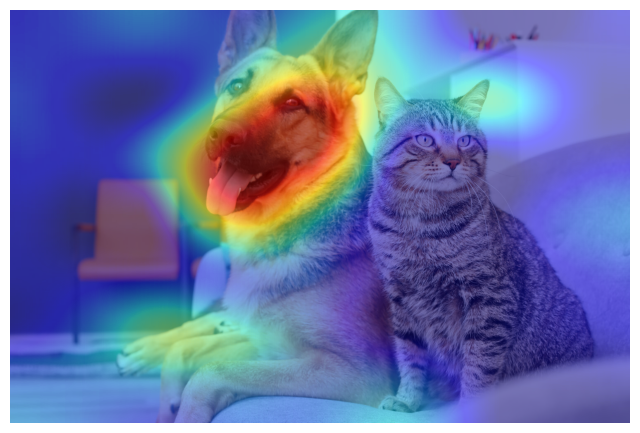

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Loading VGG-16 model
model = models.vgg16(pretrained=True)
model.eval()

# Defining the image transformation
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Loading and preprocessing the image
img_path = '/content/dog_and_cat.jpeg'
img = Image.open(img_path)
img_tensor = preprocess(img)
img_tensor = img_tensor.unsqueeze(0)  # batch dimension

# Hook
gradients = None
activations = None

def save_gradient(grad):
    global gradients
    gradients = grad

def save_activation(module, input, output):
    global activations
    activations = output

# Registering hooks to the last convolutional layer
final_conv_layer = model.features[-1]
final_conv_layer.register_forward_hook(save_activation)
final_conv_layer.register_backward_hook(lambda module, grad_in, grad_out: save_gradient(grad_out[0]))

# Performing forward pass
output = model(img_tensor)
_, predicted = output.max(1)

# Performing backpropagation
score = output[0, predicted]
model.zero_grad()
score.backward()

# Ensuring gradients and activations are captured correctly
if gradients is None or activations is None:
    raise RuntimeError("Gradients or activations not captured")

# Processing the gradients
gradients = gradients.detach().cpu().numpy()

# Processing the activations
activations = activations.detach().cpu().numpy()

# Computing the weights for the CAM
weights = np.mean(gradients, axis=(2, 3))[0, :]

# Computing the CAM
cam = np.zeros(activations.shape[2:], dtype=np.float32)
for i, w in enumerate(weights):
    cam += w * activations[0, i, :, :]

# Normalizing the CAM
cam = np.maximum(cam, 0)
cam = cam - np.min(cam)
cam = cam / np.max(cam)
cam = np.uint8(255 * cam)

# Resizing the CAM to the original image size
original_img = Image.open(img_path)
cam = Image.fromarray(cam)
cam = cam.resize(original_img.size, Image.ANTIALIAS)
cam = np.array(cam)

# Converting the image to numpy and denormalize
original_img_np = np.array(original_img)

# Overlaying the CAM on the original image
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(original_img_np)
ax.imshow(cam, cmap='jet', alpha=0.5)
plt.axis('off')
plt.show()
